# Hyperparameter optimization
- this notebook shows basic libraries and procedures used for hyperparameter optimization

# Import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
RANDOM_STATE = 12

# Create dataset for binary classification
- function `make_classification` from sklearn.datasets allows to create dataset for multiclass classification problem. Inside several features are predictive, some features can be correlated and some features are uninformative with respect to target.
- through function parameters we can control number of predictive features, number of target classes and other characteristics of the sample

In [3]:
from sklearn.datasets import make_classification

In [4]:
X, y = make_classification(
    n_samples=100000, 
    n_features=15, 
    n_informative=2, 
    n_redundant=2, 
    n_repeated=0,
    n_classes=2,
    flip_y=0.1,
    random_state=RANDOM_STATE
)

# Split sample

It is recommended to use stratification.

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y
)

# Hyper-parameters optimization
Hyper-parameters are parameters not directly learned by estimator. They must be passed to the estimator as its parameters.

Search consists of:
- estimator
- parameter search space
- method for searching the space
- score function

Basic approaches for optimal hyper-parameters selection:
    
    1. Grid search
    2. Randomized grid search
    3. Grid search with halving
    4. Randomized grid search with halving
    
**Cross validation** is usually used during hyper-parameters optimization process.

In [7]:
from sklearn.tree import DecisionTreeClassifier

## Grid search
Perfoms exhaustive grid search - every combination from search space is evaluated.

In [8]:
from sklearn.model_selection import GridSearchCV

In [9]:
params_grid = [
    {'max_depth': [2, 4, 8, 16], 'criterion': ['gini', 'entropy']},
#     {'min_samples_split': [100, 1000, 10000], 'ccp_alpha': [0.0, 0.0001, 0.00025]},
]

tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

clf = GridSearchCV(
    estimator=tree, 
    param_grid=params_grid, 
    cv=3,
    scoring='roc_auc',
    error_score=0,
    refit=False
)

clf.fit(X_train, y_train)

GridSearchCV(cv=3, error_score=0,
             estimator=DecisionTreeClassifier(random_state=12),
             param_grid=[{'criterion': ['gini', 'entropy'],
                          'max_depth': [2, 4, 8, 16]}],
             refit=False, scoring='roc_auc')

In [10]:
clf.best_params_

{'criterion': 'entropy', 'max_depth': 4}

In [11]:
pd.DataFrame(clf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.201047,0.033658,0.002008,0.002839,gini,2,"{'criterion': 'gini', 'max_depth': 2}",0.916078,0.919098,0.916121,0.917099,0.001414,6
1,0.352148,0.024046,0.007969,0.005991,gini,4,"{'criterion': 'gini', 'max_depth': 4}",0.928344,0.934119,0.931198,0.931220,0.002358,2
2,0.586870,0.016264,0.006055,0.001870,gini,8,"{'criterion': 'gini', 'max_depth': 8}",0.928104,0.933826,0.928471,0.930134,0.002615,4
3,1.291903,0.060246,0.015555,0.005330,gini,16,"{'criterion': 'gini', 'max_depth': 16}",0.861206,0.862736,0.868843,0.864262,0.003299,8
4,0.257995,0.009713,0.000000,0.000000,entropy,2,"{'criterion': 'entropy', 'max_depth': 2}",0.918413,0.920260,0.916947,0.918540,0.001355,5
5,0.492864,0.048173,0.000000,0.000000,entropy,4,"{'criterion': 'entropy', 'max_depth': 4}",0.932525,0.935843,0.932795,0.933721,0.001505,1
6,0.872685,0.034573,0.004851,0.003483,entropy,8,"{'criterion': 'entropy', 'max_depth': 8}",0.933245,0.931595,0.926431,0.930423,0.002902,3
7,1.596970,0.125774,0.013477,0.004064,entropy,16,"{'criterion': 'entropy', 'max_depth': 16}",0.869506,0.872304,0.868041,0.869950,0.001769,7


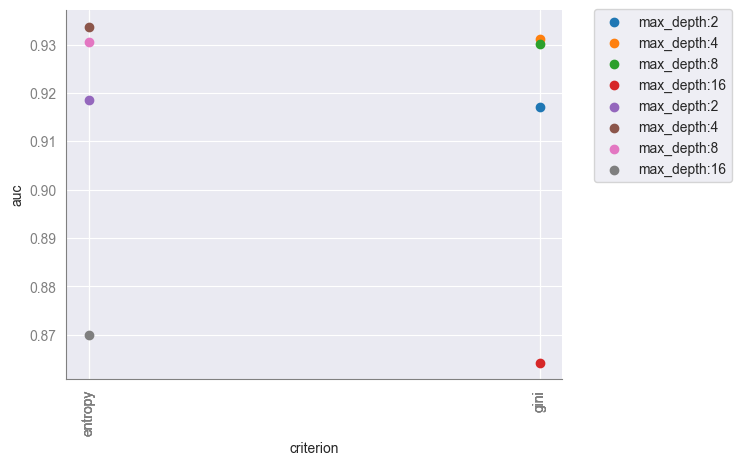

In [12]:
param = 'criterion'

x = []
y = []
other_pars = []
i = 0
for pars in clf.cv_results_['params']:
    if param in pars:
        x.append(pars[param] or -999)
        y.append(clf.cv_results_['mean_test_score'][i])
        other_pars.append(', '.join([f'{p}:{v}' for p, v in pars.items() if p != param]))
        i += 1

encoding = {}
j = 1
for i in np.unique(x):
    encoding[i] = j
    j += 1
    
xe = [encoding[i] for i in x]

ax = plt.subplot(1,1,1)
for i in range(len(x)):
    ax.scatter(xe[i], y[i], label=other_pars[i])

ax.legend(bbox_to_anchor=(1.05, 1.02))
ax.set_xticks(xe)
ax.set_xticklabels(x, rotation = 90, color='gray')
ax.set_xlabel(param)
ax.set_ylabel('auc')
ax.tick_params(axis='y', colors='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['bottom'].set_color('gray')
plt.show()

## Randomized grid search
Parameter value is selected from a distribution of possible values.

- Number of evaluated combinations can be restricted independently on number of parameters and their possible values.
- Parameters with low impact do not decrease efficiency.

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from scipy.stats import expon

In [14]:
params_dist = [
#     {'max_depth': [2, 3, 4, None], 'criterion': ['gini', 'entropy']},
    {'min_samples_split': np.unique(np.logspace(1, 4, num=30, dtype=int)), 'ccp_alpha': expon(scale=0.00025)},
]

tree = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=8)

# Budget is controlled through parameter n_iter
clf = RandomizedSearchCV(
    estimator=tree, 
    param_distributions=params_dist, 
    cv=3,
    scoring='roc_auc',
    n_iter = 8,
    error_score=0,
    refit=True,
    random_state=RANDOM_STATE
)

clf.fit(X_train, y_train)

RandomizedSearchCV(cv=3, error_score=0,
                   estimator=DecisionTreeClassifier(max_depth=8,
                                                    random_state=12),
                   n_iter=8,
                   param_distributions=[{'ccp_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000251BFEF0400>,
                                         'min_samples_split': array([   10,    12,    16,    20,    25,    32,    41,    52,    67,
          85,   108,   137,   174,   221,   280,   356,   452,   573,
         727,   923,  1172,  1487,  1887,  2395,  3039,  3856,  4893,
        6210,  7880, 10000])}],
                   random_state=12, scoring='roc_auc')

In [15]:
clf.best_params_

{'ccp_alpha': 0.00010787974904284701, 'min_samples_split': 573}

In [16]:
pd.options.display.max_columns = 100
pd.DataFrame(clf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.709279,0.013921,0.005388,0.007620,0.000042,41,"{'ccp_alpha': 4.185710574647497e-05, 'min_samp...",0.936859,0.940174,0.936710,0.937915,0.001599,5
1,0.769302,0.070119,0.006579,0.006669,0.000517,16,"{'ccp_alpha': 0.0005166553232029754, 'min_samp...",0.932831,0.937851,0.932601,0.934428,0.002423,6
2,0.649335,0.041229,0.007948,0.006548,0.000191,174,"{'ccp_alpha': 0.00019075263987516452, 'min_sam...",0.938724,0.940429,0.938583,0.939245,0.000839,3
3,0.634452,0.002813,0.004901,0.003865,0.000108,573,"{'ccp_alpha': 0.00010787974904284701, 'min_sam...",0.939698,0.941424,0.939659,0.940260,0.000823,1
4,0.730835,0.092401,0.003353,0.004741,0.000577,221,"{'ccp_alpha': 0.0005774398268521484, 'min_samp...",0.932815,0.937851,0.931330,0.933999,0.002791,7
5,0.680896,0.037844,0.014810,0.008382,0.000022,137,"{'ccp_alpha': 2.1532326366700412e-05, 'min_sam...",0.938428,0.941806,0.938106,0.939447,0.001674,2
6,0.810014,0.108984,0.003925,0.002778,0.000037,10,"{'ccp_alpha': 3.689579203427031e-05, 'min_samp...",0.930560,0.935196,0.932461,0.932739,0.001903,8
7,0.666605,0.023726,0.012520,0.004785,0.000282,174,"{'ccp_alpha': 0.00028175107515881375, 'min_sam...",0.938487,0.939085,0.938109,0.938560,0.000402,4


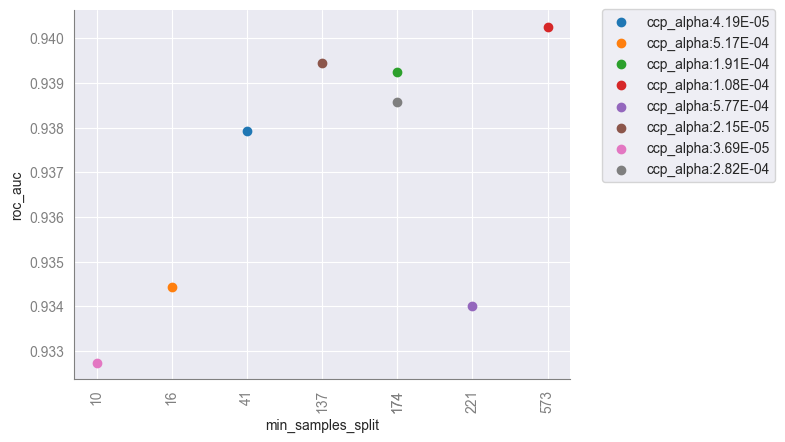

In [17]:
param = 'min_samples_split'
metric = 'roc_auc'

x = []
y = []
other_pars = []
i = 0
for pars in clf.cv_results_['params']:
    if param in pars:
        x.append(pars[param] or -999)
        y.append(clf.cv_results_[f'mean_test_score'][i])
        other_pars.append(', '.join([f'{p}:{v:.2E}' if p=='ccp_alpha' else f'{p}:{v}' for p, v in pars.items() if p != param]))
        i += 1

encoding = {}
j = 1
for i in np.unique(x):
    encoding[i] = j
    j += 1
    
xe = [encoding[i] for i in x]

ax = plt.subplot(1,1,1)
for i in range(len(x)):
    ax.scatter(xe[i], y[i], label=other_pars[i])

ax.legend(bbox_to_anchor=(1.05, 1.02))
ax.set_xticks(xe)
ax.set_xticklabels(x, rotation = 90, color='gray')
ax.set_xlabel(param)
ax.set_ylabel(metric)
ax.tick_params(axis='y', colors='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['bottom'].set_color('gray')
plt.show()

## Randomized grid search with halving
Halving allows to optimize resources allocation for optimization process. First, lot of parameters combinations are evaluated using small amount of resources. In next iteration only combinations with biggest potential are considered and evaluated again with more resources.

Important parametres of halving process:
- resource: Resource to be increased in each iteration. By default resource is number of observations to be used for cross validation. But it can be for instance number of trees to be used in random forest classifier.
- n_candidates: Number of parameters combinations to be evaluated in first iteration.
- min_resources: Amount of resources to be used in first iteration.
- factor: In each iteration resources are multiplied by factor and number of candidetes is divided by factor. If factor = 2 and iteration i uses 1000 observation, then iteration i+1 will use i\*factor = 2000 observations. Number of candidetes in i+t-th iteration is number of candidates in i-th iteration divided by factor (and with decimal part removed).

In [18]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from scipy.stats import expon

In [19]:
params_dist = [
    {
        'max_depth': [2, 4, 8, 16], 
        'criterion': ['gini', 'entropy'],
        'min_samples_split': np.unique(np.logspace(1, 4, num=30, dtype=int)), 
        'ccp_alpha': expon(scale=0.00025)
    }
]

tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

clf = HalvingRandomSearchCV(
    estimator=tree,
    param_distributions=params_dist,
    n_candidates=50,
    factor=2,
    resource='n_samples',
    min_resources='exhaust',
    cv=3,
    scoring='roc_auc',
    error_score=0,
    refit=False,
    random_state=RANDOM_STATE
)

clf.fit(X_train, y_train)

HalvingRandomSearchCV(cv=3, error_score=0,
                      estimator=DecisionTreeClassifier(random_state=12),
                      factor=2, min_resources='exhaust', n_candidates=50,
                      param_distributions=[{'ccp_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000025196E34A60>,
                                            'criterion': ['gini', 'entropy'],
                                            'max_depth': [2, 4, 8, 16],
                                            'min_samples_split': array([   10,    12,    16,    20,    25,    32,    41,    52,    67,
          85,   108,   137,   174,   221,   280,   356,   452,   573,
         727,   923,  1172,  1487,  1887,  2395,  3039,  3856,  4893,
        6210,  7880, 10000])}],
                      random_state=12, refit=False, scoring='roc_auc')

In [20]:
clf.best_params_

{'ccp_alpha': 0.00018642861979332675,
 'criterion': 'gini',
 'max_depth': 8,
 'min_samples_split': 452}

In [21]:
pd.DataFrame(clf.cv_results_)

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,param_criterion,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,0,1562,0.011813,0.013959,0.006197,0.008764,0.000042,gini,4,573,"{'ccp_alpha': 4.185710574647497e-05, 'criterio...",0.865811,0.870502,0.867433,0.867915,0.001945,88,0.882829,0.901431,0.895350,0.893203,0.007745
1,0,1562,0.009676,0.007341,0.004421,0.004901,0.000023,entropy,2,452,"{'ccp_alpha': 2.259999036479146e-05, 'criterio...",0.919634,0.923081,0.908005,0.916907,0.006450,63,0.928970,0.943299,0.926745,0.933005,0.007336
2,0,1562,0.013786,0.005999,0.001339,0.001893,0.000628,gini,4,221,"{'ccp_alpha': 0.0006275469087660558, 'criterio...",0.923614,0.925685,0.903626,0.917642,0.009947,61,0.940501,0.959431,0.942115,0.947349,0.008568
3,0,1562,0.026963,0.006500,0.002093,0.001745,0.000022,entropy,8,108,"{'ccp_alpha': 2.1532326366700412e-05, 'criteri...",0.929502,0.926506,0.920032,0.925347,0.003952,41,0.966597,0.977314,0.970812,0.971574,0.004408
4,0,1562,0.001337,0.001891,0.000581,0.000821,0.000083,gini,2,221,"{'ccp_alpha': 8.34588525616488e-05, 'criterion...",0.910691,0.923081,0.904558,0.912777,0.007704,75,0.922056,0.943299,0.925642,0.930332,0.009285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,4,24992,0.260618,0.022486,0.003916,0.005538,0.000207,entropy,4,221,"{'ccp_alpha': 0.00020703627629944653, 'criteri...",0.932666,0.936954,0.932412,0.934011,0.002084,23,0.935564,0.937520,0.938523,0.937203,0.001229
97,4,24992,0.495995,0.053571,0.012053,0.005684,0.000022,entropy,8,108,"{'ccp_alpha': 2.1532326366700412e-05, 'criteri...",0.939500,0.939239,0.935311,0.938017,0.001916,4,0.948930,0.950763,0.951637,0.950443,0.001128
98,4,24992,0.293255,0.022502,0.002704,0.003824,0.000186,gini,8,452,"{'ccp_alpha': 0.00018642861979332675, 'criteri...",0.941434,0.941218,0.937089,0.939914,0.001999,1,0.943348,0.942545,0.942727,0.942873,0.000344
99,5,49984,1.222844,0.059067,0.015363,0.011753,0.000022,entropy,8,108,"{'ccp_alpha': 2.1532326366700412e-05, 'criteri...",0.938720,0.938526,0.938089,0.938445,0.000264,3,0.946179,0.947238,0.946714,0.946710,0.000432


In [22]:
cvres = pd.DataFrame(clf.cv_results_)

cvres.groupby('iter')['iter'].count()

iter
0    50
1    25
2    13
3     7
4     4
5     2
Name: iter, dtype: int64

C:\Users\pkank\AppData\Local\Temp\ipykernel_6916\1799170098.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cvres[['iter', 'n_resources']].drop_duplicates().apply(lambda row: f'iter: {row[0]}\n resources: {row[1]}', axis = 1).to_list(),


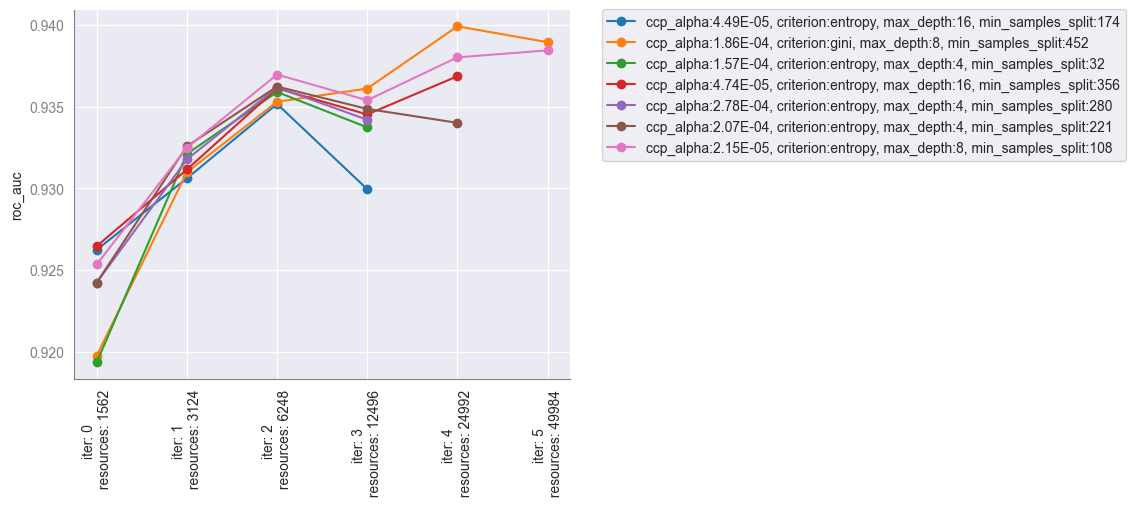

In [23]:
cvres = pd.DataFrame(clf.cv_results_)
param_combs = cvres[cvres['iter'] == 3]['params'].to_list()

cvres_res = pd.DataFrame()
ax = plt.subplot(1,1,1)
for pc in param_combs:
    dt = cvres[cvres['params'] == pc]
    label = ', '.join([f'{p}:{v:.2E}' if p=='ccp_alpha' else f'{p}:{v}' for p,v in pc.items()])
    ax.plot(dt['iter'], dt['mean_test_score'], marker='o', label=label)

ax.set_xticks(dt['iter'])
ax.set_xticklabels(
    cvres[['iter', 'n_resources']].drop_duplicates().apply(lambda row: f'iter: {row[0]}\n resources: {row[1]}', axis = 1).to_list(), 
    rotation=90
)

ax.legend(bbox_to_anchor=(1.05, 1.02))
ax.set_ylabel(metric)
ax.tick_params(axis='y', colors='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['bottom'].set_color('gray')
plt.show()

## Searching hyperparameters in pipeline 

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV

<span style="color:red">**TO DO:** Study [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) to understand the Pipeline object. </span>

In [25]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

pipe = Pipeline([
    ('select', SelectKBest()),
    ('model', tree)
])

param_grid = {
    'select__k': [5, 10, 15],
    'model__max_depth': [2, 4, 6, 8]
}

search = GridSearchCV(pipe, param_grid, cv=3).fit(X_train, y_train)

In [26]:
search.best_params_

{'model__max_depth': 6, 'select__k': 5}

In [27]:
dt = pd.DataFrame(search.cv_results_)
dt

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_select__k,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.080682,0.003516,0.004738,0.001674,2,5,"{'model__max_depth': 2, 'select__k': 5}",0.884922,0.888942,0.883355,0.88574,0.002353,10
1,0.152244,0.013316,0.003572,0.002830,2,10,"{'model__max_depth': 2, 'select__k': 10}",0.884922,0.888942,0.883355,0.88574,0.002353,10
2,0.201761,0.014240,0.001338,0.001893,2,15,"{'model__max_depth': 2, 'select__k': 15}",0.884922,0.888942,0.883355,0.88574,0.002353,10
3,0.139343,0.015947,0.001381,0.001953,4,5,"{'model__max_depth': 4, 'select__k': 5}",0.897522,0.902562,0.898956,0.89968,0.002120,9
4,0.285047,0.039135,0.007909,0.005800,4,10,"{'model__max_depth': 4, 'select__k': 10}",0.897582,0.904122,0.898956,0.90022,0.002816,8
5,0.436025,0.095435,0.000000,0.000000,4,15,"{'model__max_depth': 4, 'select__k': 15}",0.897582,0.904122,0.900036,0.90058,0.002697,7
6,0.272894,0.016796,0.001338,0.001893,6,5,"{'model__max_depth': 6, 'select__k': 5}",0.902022,0.905922,0.902316,0.90342,0.001773,1
7,0.371490,0.025076,0.008810,0.004131,6,10,"{'model__max_depth': 6, 'select__k': 10}",0.899442,0.905022,0.902556,0.90234,0.002283,3
8,0.562136,0.015915,0.008422,0.005991,6,15,"{'model__max_depth': 6, 'select__k': 15}",0.898122,0.903282,0.901956,0.90112,0.002188,5
9,0.231208,0.017856,0.001251,0.001769,8,5,"{'model__max_depth': 8, 'select__k': 5}",0.901902,0.906102,0.900096,0.90270,0.002516,2


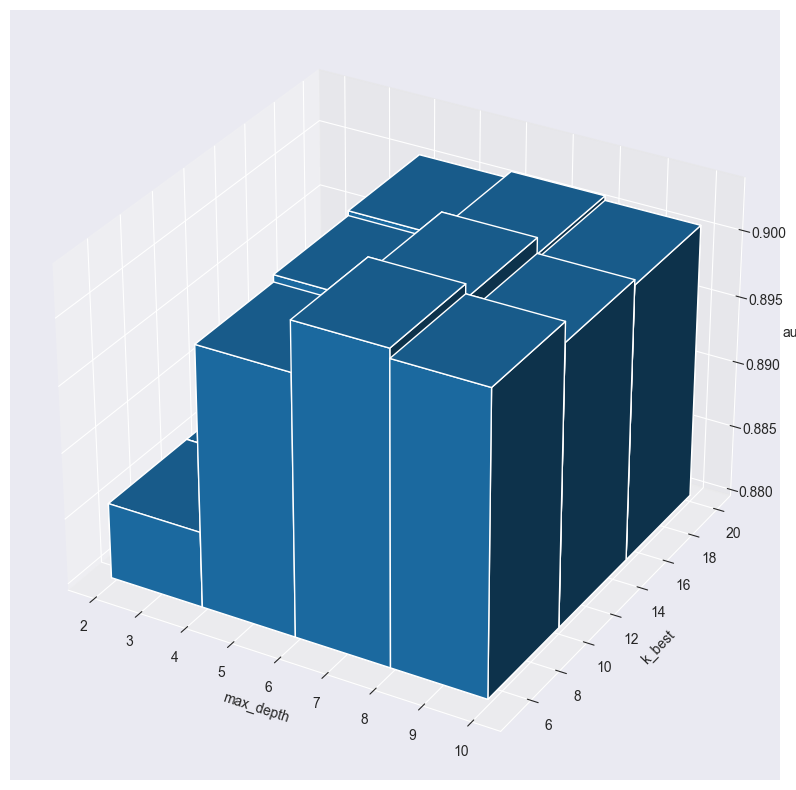

In [28]:
# setup the figure and axes
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(111, projection='3d')

_x = [2, 4, 6, 8]
_y = [5, 10, 15]
_yy, _xx = np.meshgrid(_y, _x)
x, y = _xx.ravel(), _yy.ravel()

top = dt['mean_test_score']-0.88
bottom = np.zeros_like(top)+0.88
width = 2
depth = 5

ax1.bar3d(x, y, bottom, width, depth, top, shade=True)

ax1.set_xlabel('max_depth')
ax1.set_ylabel('k_best')
ax1.set_zlabel('auc')

plt.show()

## Hyperopt
Hyperopt is a library for serial and parallel optimization. Uses Bayesian Optimization principles.

To use hyperopt we need to describe:
1. The objective function to minimize
2. Search space
3. Database to be used for storing results 
4. Search algorithm

Unfortunately, documentation is poor for hyperopt library. Some detils may be found at <a href="https://github.com/hyperopt/hyperopt/wiki/FMin" target="_top">hyperopt tutorial</a>.

In [29]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score

In [30]:
# function to be minimized
def objective(params):
    tree = DecisionTreeClassifier(
        random_state=RANDOM_STATE, 
        max_depth=params['max_depth'],
        ccp_alpha=params['ccp_alpha']
    )
    scores = cross_val_score(estimator=tree, X=X_train, y=y_train, cv=3, n_jobs=4, scoring='roc_auc')
    
    return {
        'status': STATUS_OK,
        'loss': -np.mean(scores),
        'std_score': np.std(scores)
    }

# database for storing results
trials = Trials()

# space to be searched
search_space = {
    'max_depth': hp.choice('max_depth', np.arange(1, 8, dtype=int)),
    'ccp_alpha': hp.uniform('ccp_alpha', 0.0, 0.00025)
}

# actual minimization
best = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
#     algo=tpe.rand.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(RANDOM_STATE)
)

100%|██████████| 50/50 [00:35<00:00,  1.40trial/s, best loss: -0.939699981587866] 


In [31]:
best

{'ccp_alpha': 0.00015155721456800486, 'max_depth': 6}

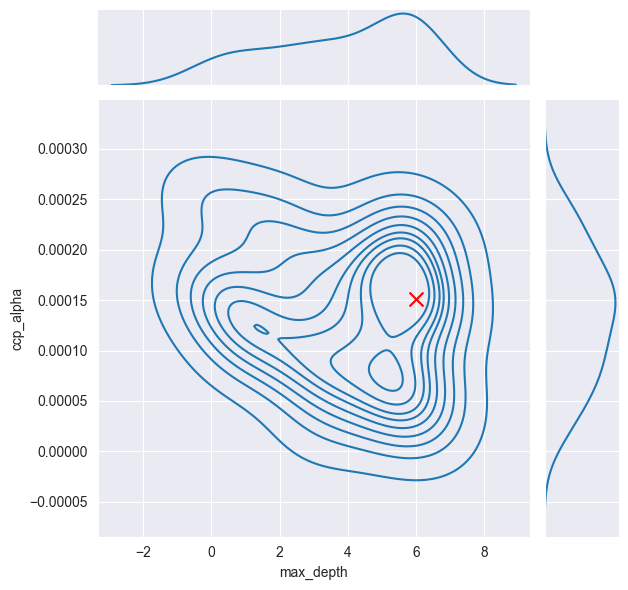

In [32]:
import seaborn as sns

md = []
alpha = []
for tr in trials.trials:
    md.append(tr['misc']['vals']['max_depth'][0])
    alpha.append(tr['misc']['vals']['ccp_alpha'][0])
    
dt = pd.DataFrame(zip(md, alpha), columns=['max_depth', 'ccp_alpha'])

# plt.scatter(best['max_depth'], best['ccp_alpha'], marker='x', color='red')
p = sns.jointplot(data=dt, x="max_depth", y="ccp_alpha", kind='kde')
p.ax_joint.scatter(best['max_depth'], best['ccp_alpha'], marker='x', color='red', s=100)

plt.show()

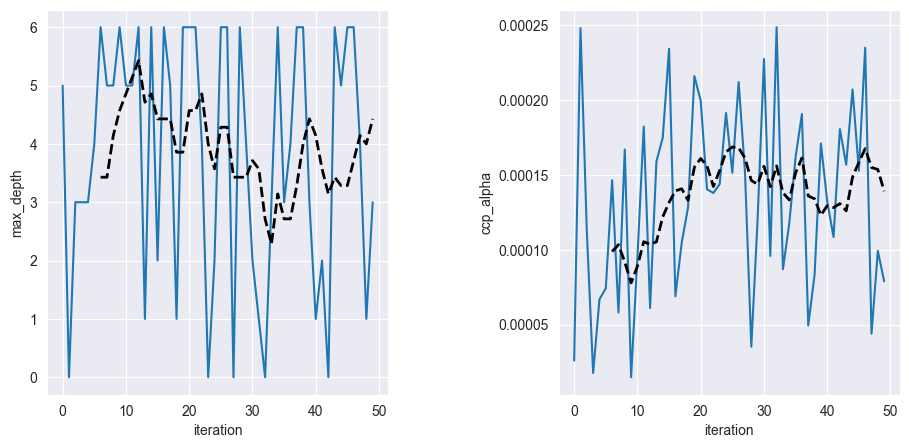

In [33]:
fig = plt.figure(figsize=(11,5))

plt.subplots_adjust(wspace=0.5)
plt.subplot(1,2,1)
plt.plot(dt.index, dt['max_depth'])
plt.xlabel('iteration')
plt.ylabel('max_depth')
plt.plot(dt.index, dt['max_depth'].rolling(window=7).mean(), ls='--', color='black', lw=2)

plt.subplot(1,2,2)
plt.plot(dt.index, dt['ccp_alpha'])
plt.plot(dt.index, dt['ccp_alpha'].rolling(window=7).mean(), ls='--', color='black', lw=2)
plt.xlabel('iteration')
plt.ylabel('ccp_alpha')

plt.show()

## Genetic algorithm

In [ ]:
from scipy.optimize import differential_evolution
from sklearn.model_selection import cross_val_score

<span style="color:red">**TO DO:** Study [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.differential_evolution.html) to understand the best1bin strategy and other parameters. </span>

In [ ]:
res = []

def objective(params, X, y):
    ccp_alpha, max_depth = params
    max_depth = round(max_depth)
    
    tree = DecisionTreeClassifier(
        random_state=RANDOM_STATE, 
        max_depth=max_depth, 
        ccp_alpha=ccp_alpha
    )
    
    scores = cross_val_score(estimator=tree, X=X, y=y, cv=3, n_jobs=4, scoring='roc_auc')
    print(f'ccp_alpha: {ccp_alpha:.7f};   max_depth: {max_depth};   mean score: {np.mean(scores):.5f}')
    res.append((ccp_alpha, max_depth, np.mean(scores)))
    return -np.mean(scores)

In [ ]:
ccpalpha_bound = (0.0001, 0.00025)
maxdepth_bound = (1, 8)

boundaries = [ccpalpha_bound, maxdepth_bound]
solver = differential_evolution(
    objective,
    boundaries,
    args=(X_train, y_train),
    strategy='best1bin',
    maxiter=2,
    popsize=15,
    mutation=0.5,
    recombination=0.7,
    tol=0.01,
    seed=RANDOM_STATE
)

In [ ]:
print('Best parameters:')
print('----------------')
print(f'ccp_alpha:   {solver.x[0]}')
print(f'max_depth:   {round(solver.x[1])}')

In [ ]:
res = pd.DataFrame(res, columns=['ccp_alpha', 'max_depth', 'mean_score'])

fig = plt.figure(figsize=(11,5))
plt.subplots_adjust(wspace=0.5)
plt.subplot(1,2,1)
sns.histplot(res['max_depth'], color='blue')

plt.subplot(1,2,2)
sns.histplot(res['ccp_alpha'], color='red')

plt.show()

<span style="color:red">**TO DO:** Optimize hyperparameters for an xgboost model. Define which parameters to optimize and compare multiple methods</span>

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 1. LOAD & PREP BLIND DATA
# ==========================================
blind_test = pd.read_csv('Data/2025_DS2_HW1_data_test.csv')

# rename columns exactly as in training
rename_dict = {
    'no_of_adults': 'adults', 'no_of_children': 'children',
    'no_of_weekend_nights': 'weekend_nights', 'no_of_week_nights': 'week_nights',
    'type_of_meal_plan': 'meal_plan', 'required_car_parking_space': 'parking_space',
    'room_type_reserved': 'room_type', 'market_segment_type': 'market_segment',
    'repeated_guest': 'repeated_guest', 'no_of_previous_cancellations': 'prev_cancellations',
    'no_of_previous_bookings_not_canceled': 'prev_not_canceled',
    'avg_price_per_room': 'avg_price', 'no_of_special_requests': 'special_requests'
}
blind_test = blind_test.rename(columns=rename_dict)

# feature engineering replication
year_str = pd.to_numeric(blind_test['arrival_year'], errors='coerce').fillna(-1).astype(int).astype(str)
month_str = pd.to_numeric(blind_test['arrival_month'], errors='coerce').fillna(-1).astype(int).astype(str)
day_str = pd.to_numeric(blind_test['arrival_date'], errors='coerce').fillna(-1).astype(int).astype(str)

blind_test['arrival_date_full'] = pd.to_datetime(
    year_str + '-' + month_str + '-' + day_str, format='%Y-%m-%d', errors='coerce'
)
blind_test['arrival_day_of_week'] = blind_test['arrival_date_full'].dt.dayofweek

blind_test['total_prev_bookings'] = blind_test['prev_cancellations'] + blind_test['prev_not_canceled']
blind_test['prev_cancel_rate'] = (blind_test['prev_cancellations'] / blind_test['total_prev_bookings']).fillna(0)

blind_test['total_guests'] = blind_test['adults'] + blind_test['children']
blind_test['total_stay'] = blind_test['weekend_nights'] + blind_test['week_nights']

imposters = ['parking_space', 'repeated_guest', 'arrival_year', 'arrival_month', 'arrival_date', 'arrival_day_of_week']
for col in imposters:
    if col in blind_test.columns:
        blind_test[col] = blind_test[col].astype('category')

# Retrieve the exact columns the imputers expect
num_cols_trained = num_imputer.feature_names_in_.tolist()
cat_cols_trained = cat_imputer.feature_names_in_.tolist()

for col in num_cols_trained + cat_cols_trained:
    if col not in blind_test.columns:
        blind_test[col] = np.nan

# Transform Numbers & Categories
X_blind_num_imputed = num_imputer.transform(blind_test[num_cols_trained])
num_imputed_names = num_imputer.get_feature_names_out(num_cols_trained)
X_blind_cat_imputed = cat_imputer.transform(blind_test[cat_cols_trained])

X_blind_imputed = pd.DataFrame(X_blind_num_imputed, columns=num_imputed_names, index=blind_test.index)
X_blind_imputed[cat_cols_trained] = X_blind_cat_imputed

# Apply the Ordinal Encoder (with the string fix)
X_blind_trees = X_blind_imputed.copy()
X_blind_trees[cat_cols_trained] = X_blind_trees[cat_cols_trained].astype(str)
X_blind_trees[cat_cols_trained] = ordinal_enc.transform(X_blind_trees[cat_cols_trained])

final_predictors = [
    'special_requests', 'lead_time', 'arrival_year', 'arrival_month',
    'avg_price', 'market_segment', 'adults', 'week_nights',
    'weekend_nights', 'total_prev_bookings', 'prev_cancel_rate',
    'meal_plan', 'repeated_guest', 'parking_space'
]

X_final = X_blind_trees[final_predictors]

# ==========================================
# 2. PREDICT RAW PROBABILITIES & SAVE
# ==========================================
print("Generating final probabilities using Optuna Champion...")
# This outputs floats between 0.0000 and 1.0000
final_submission_probs = best_xgb_optuna.predict_proba(X_final)[:, 1]

submission_df = pd.DataFrame({
    'Booking_ID': blind_test['Booking_ID'],
    'prediction': final_submission_probs
})

# Saved with a clear name so you know it's the raw probabilities
submission_df.to_csv('final_xgboost_optuna_probabilities.csv', index=False)
print(f"Success! Exported {len(submission_df)} probability predictions to 'final_xgboost_optuna_probabilities.csv'.")

In [ ]:

# blind test data
blind_test = pd.read_csv('Data/2025_DS2_HW1_data_test.csv')

#rename columns exactly as in training
rename_dict = {
    'no_of_adults': 'adults',
    'no_of_children': 'children',
    'no_of_weekend_nights': 'weekend_nights',
    'no_of_week_nights': 'week_nights',
    'type_of_meal_plan': 'meal_plan',
    'required_car_parking_space': 'parking_space',
    'room_type_reserved': 'room_type',
    'market_segment_type': 'market_segment',
    'repeated_guest': 'repeated_guest',
    'no_of_previous_cancellations': 'prev_cancellations',
    'no_of_previous_bookings_not_canceled': 'prev_not_canceled',
    'avg_price_per_room': 'avg_price',
    'no_of_special_requests': 'special_requests'
}
blind_test = blind_test.rename(columns=rename_dict)

#feature engineering replication
# Dates
year_str = pd.to_numeric(blind_test['arrival_year'], errors='coerce').fillna(-1).astype(int).astype(str)
month_str = pd.to_numeric(blind_test['arrival_month'], errors='coerce').fillna(-1).astype(int).astype(str)
day_str = pd.to_numeric(blind_test['arrival_date'], errors='coerce').fillna(-1).astype(int).astype(str)

blind_test['arrival_date_full'] = pd.to_datetime(
    year_str + '-' + month_str + '-' + day_str,
    format='%Y-%m-%d',
    errors='coerce'
)
blind_test['arrival_day_of_week'] = blind_test['arrival_date_full'].dt.dayofweek

# Historical Rates
blind_test['total_prev_bookings'] = blind_test['prev_cancellations'] + blind_test['prev_not_canceled']
blind_test['prev_cancel_rate'] = (blind_test['prev_cancellations'] / blind_test['total_prev_bookings']).fillna(0)

# Aggregates
blind_test['total_guests'] = blind_test['adults'] + blind_test['children']
blind_test['total_stay'] = blind_test['weekend_nights'] + blind_test['week_nights']

# Categorical Imposters
imposters = [
    'parking_space', 'repeated_guest', 'arrival_year',
    'arrival_month', 'arrival_date', 'arrival_day_of_week'
]
for col in imposters:
    if col in blind_test.columns:
        blind_test[col] = blind_test[col].astype('category')


# Retrieve the exact columns the imputers from training
num_cols_trained = num_imputer.feature_names_in_.tolist()
cat_cols_trained = cat_imputer.feature_names_in_.tolist()

#If the test set is completely missing a column the imputer expects, fill it with NaN
for col in num_cols_trained + cat_cols_trained:
    if col not in blind_test.columns:
        blind_test[col] = np.nan

# Transform Numbers
X_blind_num_imputed = num_imputer.transform(blind_test[num_cols_trained])
num_imputed_names = num_imputer.get_feature_names_out(num_cols_trained)

# Transform Categories
X_blind_cat_imputed = cat_imputer.transform(blind_test[cat_cols_trained])

# Rebuild DataFrame like in training
X_blind_imputed = pd.DataFrame(X_blind_num_imputed, columns=num_imputed_names, index=blind_test.index)
X_blind_imputed[cat_cols_trained] = X_blind_cat_imputed

# Apply the Ordinal Encoder to the categorical columns
X_blind_trees = X_blind_imputed.copy()
X_blind_trees[cat_cols_trained] = ordinal_enc.transform(X_blind_trees[cat_cols_trained])


final_predictors = [
    'special_requests', 'lead_time', 'arrival_year', 'arrival_month',
    'avg_price', 'market_segment', 'adults', 'week_nights',
    'weekend_nights', 'total_prev_bookings', 'prev_cancel_rate',
    'meal_plan', 'repeated_guest', 'parking_space'
]

X_final = X_blind_trees[final_predictors]

print("final probabilities using best XGBoost...")
final_submission_probs = best_xgb.predict_proba(X_final)[:, 1]

#----- save to CSV

# Build the final dataframe
submission_df_hard = pd.DataFrame({
    'Booking_ID': blind_test['Booking_ID'],
    'prediction': final_submission_probs
})

# Save to CSV
submission_df_hard.to_csv('final_xgboost_predictions.csv', index=False)

print(f" Exported {len(submission_df_hard)} to 'final_xgboost_predictions.csv'.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the importance scores and feature names
importances = best_xgb_optuna.feature_importances_
feature_names = X_train_t.columns

# 2. Create a DataFrame and sort it from highest to lowest
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')

plt.title('XGBoost Final Model - Feature Importance', fontsize=16)
plt.xlabel('Relative Importance (Gain)', fontsize=14)
plt.ylabel('Predictors', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Calculate the class imbalance ratio (if not still in memory)
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 2. Define the Hyperopt Search Space
# We use hp.quniform for numbers we want to be integers later
# We use hp.loguniform for numbers we want to scale logarithmically (needs np.log)
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 1000, 50),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 5.0),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(0.1), np.log(50.0))
}

# 3. Define the Objective Function
def hyperopt_objective(params):
    # Hyperopt returns floats for quniform, so we MUST cast to integers here
    n_estimators = int(params['n_estimators'])
    max_depth = int(params['max_depth'])

    # Instantiate the model with the current trial's parameters
    model = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=params['learning_rate'],
        max_depth=max_depth,
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_lambda=params['reg_lambda'],
        scale_pos_weight=imbalance_ratio,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    )

    # 3-fold cross-validation
    scores = cross_val_score(model, X_train_t, y_train, cv=3, scoring='roc_auc')
    mean_auc = scores.mean()

    # TRICK: Hyperopt minimizes, so we return the NEGATIVE AUC score
    return {'loss': -mean_auc, 'status': STATUS_OK}

# 4. Run the Optimization
print("Starting Hyperopt Bayesian Optimization for XGBoost...")

trials = Trials() # This keeps track of all the results
best_hyperparams = fmin(
    fn=hyperopt_objective,
    space=space,
    algo=tpe.suggest,      # The Tree-structured Parzen Estimator algorithm
    max_evals=40,          # 40 trials, matching our previous Optuna run
    trials=trials,
    rstate=np.random.default_rng(42) # Set seed for reproducibility
)

print("\n--- Hyperopt Tuning Complete ---")
# Print the best parameters (remember to format the integers!)
print("Best Parameters Found:")
best_hyperparams['n_estimators'] = int(best_hyperparams['n_estimators'])
best_hyperparams['max_depth'] = int(best_hyperparams['max_depth'])
for key, value in best_hyperparams.items():
    print(f"    {key}: {value}")

# 5. Train the Final Champion Model
best_xgb_hyperopt = XGBClassifier(
    **best_hyperparams,
    scale_pos_weight=imbalance_ratio,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

best_xgb_hyperopt.fit(X_train_t, y_train)

# 6. Evaluate on the Hold-Out Test Set
y_pred_proba_hyperopt = best_xgb_hyperopt.predict_proba(X_test_t)[:, 1]
final_hyperopt_auc = roc_auc_score(y_test, y_pred_proba_hyperopt)

print(f"\nFinal Test Set ROC AUC Score (Hyperopt): {final_hyperopt_auc:.4f}")